# Classifier using PyTorch

In this notebook we train an MLP classifier on the MINST dataset.

In [19]:
# Inserting cell to mount drive into Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import numpy as np
import torch
import torchvision
from torch import nn, optim
from torchvision import transforms, datasets
import matplotlib.pyplot as plt

if torch.cuda.is_available():
  device_name = torch.device('cuda')
else:
  device_name = torch.device('cpu')

print(f'{device_name} is being used')

# replace with your own root directory
#ROOT="C:/Users/scsdch/OneDrive - University of Leeds/Teaching/ODL Deep Learning/workspace/"
ROOT = "/content/drive/MyDrive/Colab Notebooks/Unit2_Classifier_Files"

cuda is being used


Load the MNIST dataset. This will download a copy to your machine on first use.

In [21]:
# Load the datasets
train_set = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transforms.ToTensor()   # Transforming image dataset (which is in tuples) into tensors
)

test_set = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

Inspect some of the data.

In [22]:
data, label = train_set[4]  # get the 4th element of train_set, which returns a tensor
print(data.size())
print(label)

torch.Size([1, 28, 28])
9


Create some iterable Data Loaders for easy iteration on mini-batches during training and testing. Also, initialise an array with the 10 class IDs.

In [23]:
train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=16,
    shuffle=True,
    num_workers=2  # Number of processes used to load and process the data
)

test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=24, # Forward pass only so batch size can be larger (aka: we don't need to adjust weights with this)
    shuffle=False, # No need to shuffle as we'll only introduce more variability when it comes to comparing results
    num_workers=2
)

classes = np.arange(0, 10)
print(classes)

[0 1 2 3 4 5 6 7 8 9]


Show some images and labels as a sanity check.
Use `torchvision.utils.make_grid` to create one image from a set of images. Note that this function converts single channel (grey-scale) tensors to have three channels. This is done by replicating the values into red, green and blue channels.

torch.Size([16, 1, 28, 28])


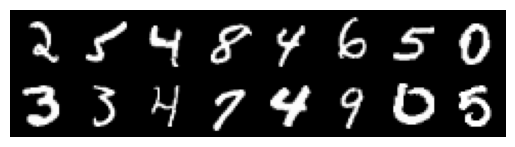

2 5 4 8 4 6 5 0 3 3 4 7 4 9 0 5


In [24]:
def timshow(x):
    xa = np.transpose(x.numpy(),(1,2,0))  # Re-orders the pytorch data matrix into the w*h*rgb format that pyplot needs
    plt.imshow(xa)
    plt.axis('off')
    plt.show()
    return xa

# get a batch of random training examples (images and corresponding labels)
dataiter = iter(train_loader)  # loads the train_loader into an iterator
images, labels = next(dataiter)  # get a single batch

# show images and labels
print(images.size())  # print the size of the tensor
timshow(torchvision.utils.make_grid(images))
print(*labels.numpy())     # asterisk unpacks the ndarray


## Build a classifier
Instead of defining the classifier function, loss function and parameter updates directly as we did in PyTorch.ipynb, it is convenient to use the `torch.nn` and `torch.optim` packages. These provide a simple way to build networks without losing sight of the iterative steps in gradient descent.

First we construct the classifer function using the nn.Sequential wrapper that simply sequences the steps in the classifier function. In the case of a linear classifier there is just one nn.Linear layer. This is preceeded by `nn.Flatten` that vectorises a $28\times28$ input image into a 1D vector of length $28*28$. We will also experiment with a two layer classifier.

In [44]:
net = nn.Sequential(
    nn.Flatten(),

    # single layer
    #nn.Linear(28*28, 10)

    # two layers
    #nn.Linear(28*28, 300),
    #nn.Sigmoid(),
    #nn.Linear(300,10)

    # three layers with ReLU
    nn.Linear(28*28, 300),
    nn.ReLU(),
    nn.Linear(300,150),
    nn.Linear(150,10)
)

for param in net.parameters():
    print(param.shape)

net.to(device_name)

torch.Size([300, 784])
torch.Size([300])
torch.Size([150, 300])
torch.Size([150])
torch.Size([10, 150])
torch.Size([10])


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=300, bias=True)
  (2): ReLU()
  (3): Linear(in_features=300, out_features=150, bias=True)
  (4): Linear(in_features=150, out_features=10, bias=True)
)

Train the network. For the two-layer network you'll need at least 200 epochs. 50 epochs will be more than enough for the one-layer network, but we'll run for the same number of epochs as for the two-layer network to give the full curve in the plot below.

In [34]:
nepochs = 200    # number of epochs

# initialise ndarray to store the mean loss in each epoch (on the training data)
losses = np.zeros(nepochs)

# Use a loss function and optimiser provided as part of PyTorch.
# The chosen optimiser (Stochastic Gradient Descent with momentum) needs only to be given the parameters (weights and biases)
# of the network and updates these when asked to perform an optimisation step below.
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

for epoch in range(nepochs):  # loop over the dataset multiple times

    # initialise variables for mean loss calculation
    running_loss = 0.0
    n = 0

    for data in train_loader:
        inputs, labels = data
        inputs, labels = inputs.to(device_name), labels.to(device_name)

        # Zero the parameter gradients to remove accumulated gradient from a previous iteration.
        # Every step we take in the SGD, the gradient needs to be independent of gradient the prior step
        optimizer.zero_grad()

        # Forward, backward, and update parameters
        outputs = net(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        # accumulate loss and increment minibatches
        running_loss += loss.item()  # because we are doing minibatches, the epoch loss = average of losses from all minibatches
        n += 1

    # record the mean loss for this epoch and show progress
    losses[epoch] = running_loss / n
    print(f"epoch: {epoch+1} loss: {losses[epoch] : .3f}")

epoch: 1 loss:  1.384
epoch: 2 loss:  0.545
epoch: 3 loss:  0.417
epoch: 4 loss:  0.369
epoch: 5 loss:  0.344
epoch: 6 loss:  0.327
epoch: 7 loss:  0.315
epoch: 8 loss:  0.306
epoch: 9 loss:  0.298
epoch: 10 loss:  0.292
epoch: 11 loss:  0.286
epoch: 12 loss:  0.280
epoch: 13 loss:  0.275
epoch: 14 loss:  0.270
epoch: 15 loss:  0.265
epoch: 16 loss:  0.261
epoch: 17 loss:  0.256
epoch: 18 loss:  0.251
epoch: 19 loss:  0.246
epoch: 20 loss:  0.242
epoch: 21 loss:  0.237
epoch: 22 loss:  0.232
epoch: 23 loss:  0.228
epoch: 24 loss:  0.224
epoch: 25 loss:  0.219
epoch: 26 loss:  0.215
epoch: 27 loss:  0.211
epoch: 28 loss:  0.207
epoch: 29 loss:  0.203
epoch: 30 loss:  0.199
epoch: 31 loss:  0.195
epoch: 32 loss:  0.191
epoch: 33 loss:  0.188
epoch: 34 loss:  0.185
epoch: 35 loss:  0.181
epoch: 36 loss:  0.178
epoch: 37 loss:  0.175
epoch: 38 loss:  0.172
epoch: 39 loss:  0.169
epoch: 40 loss:  0.166
epoch: 41 loss:  0.164
epoch: 42 loss:  0.161
epoch: 43 loss:  0.158
epoch: 44 loss:  0.1

In [35]:
#results_path = ROOT+'/Results/linear1layer200epochs.pt'
#results_path = ROOT+'/Results/linear2layer200epochs_sigmoid.pt'
results_path = ROOT+'/Results/linear2layer200epochs_relu.pt'

# save network parameters and losses
torch.save({"state_dict": net.state_dict(), "losses": losses}, results_path)

Notice that the first dimension of inputs and outputs corresponds to a minibatch of examples.

In [36]:
print(f"input size: {inputs.size()}, output size: {outputs.size()}")

input size: torch.Size([16, 1, 28, 28]), output size: torch.Size([16, 10])


Compare the history of the loss function during training (mean loss in each epoch) for 1 and 2 layer models

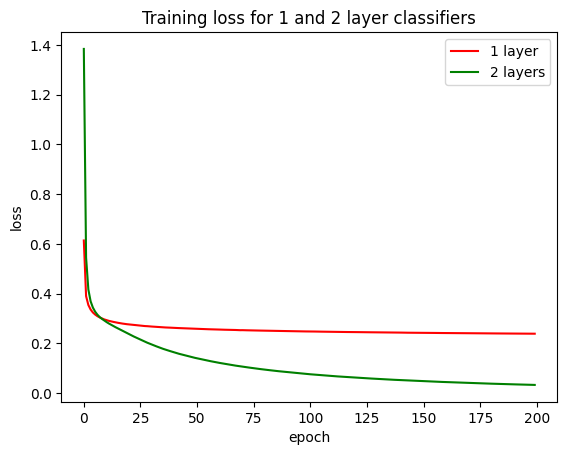

In [37]:
d1 = torch.load(ROOT+'/Results/linear1layer200epochs.pt')
d2 = torch.load(ROOT+'/Results/linear2layer200epochs_sigmoid.pt')

fig = plt.figure()

plt.plot(d1["losses"], 'r', label = '1 layer', )
plt.plot(d2["losses"], 'g', label = '2 layers' )
plt.legend()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Training loss for 1 and 2 layer classifiers')

fig.savefig("training_loss_MNIST.svg")
plt.show()

How does the trained classifier `net` perform on the test set? First define our performance measures in terms of a given confusion matrix.

In [39]:
def accuracy(cnfm):
    return cnfm.trace()/cnfm.sum((0,1))

def recalls(cnfm):
    return np.diag(cnfm)/cnfm.sum(1)

def precisions(cnfm):
    return np.diag(cnfm)/cnfm.sum(0)

Run the model on test data, build a confusion matrix and compute performance measures.

Confusion matrix
[[ 967    0    1    1    1    3    2    2    1    2]
 [   0 1123    3    1    0    1    2    2    3    0]
 [   2    1 1012    2    1    0    3    5    6    0]
 [   0    0    1  990    0    5    0    6    4    4]
 [   3    0    5    1  952    0    2    3    1   15]
 [   4    1    0    9    0  865    6    1    3    3]
 [   6    3    2    0    2    4  940    0    1    0]
 [   1    1    9    2    0    0    0 1004    3    8]
 [   4    1    3    4    4    4    4    5  941    4]
 [   2    3    0    7    7    1    1    6    2  980]]
Accuracy: 97.7%
Class 0 : Precision 97.8%  Recall 98.7%
Class 1 : Precision 99.1%  Recall 98.9%
Class 2 : Precision 97.7%  Recall 98.1%
Class 3 : Precision 97.3%  Recall 98.0%
Class 4 : Precision 98.4%  Recall 96.9%
Class 5 : Precision 98.0%  Recall 97.0%
Class 6 : Precision 97.9%  Recall 98.1%
Class 7 : Precision 97.1%  Recall 97.7%
Class 8 : Precision 97.5%  Recall 96.6%
Class 9 : Precision 96.5%  Recall 97.1%


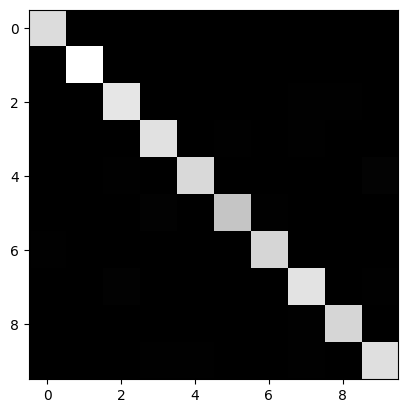

In [42]:
d = torch.load(ROOT+'/Results/linear2layer200epochs_sigmoid.pt')
# now load the parameter state into the current model (make sure this is the right model).
net.load_state_dict(d["state_dict"])

# initialise confusion matrix
nclasses = classes.shape[0]
cnfm = np.zeros((nclasses,nclasses),dtype=int)

# work without gradient computation since we are testing (i.e. no optimisation)
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        images, labels = images.to(device_name), labels.to(device_name)
        outputs = net(images)

        # find the class with the highest output.
        # note that the outputs are confidence values since we didn't need to apply softmax in our network
        # (nn.crossentropyloss takes raw condifence values and does its own softmax)
        _, predicted = torch.max(outputs, 1)


        # accumulate into confusion matrix
        for i in range(labels.size(0)):
            cnfm[labels[i].item(),predicted[i].item()] += 1

print("Confusion matrix")
print(cnfm)

# show confusion matrix as a grey-level image
plt.imshow(cnfm, cmap='gray')

# show per-class recall and precision
print(f"Accuracy: {accuracy(cnfm) :.1%}")
r = recalls(cnfm)
p = precisions(cnfm)
for i in range(nclasses):
    print(f"Class {classes[i]} : Precision {p[i] :.1%}  Recall {r[i] :.1%}")


## Defining a bespoke model class

In the above, we have used the 'container' module `nn.Sequential` to define our network. To give more flexibility in the definition of the network, we can replace this with our own `nn.module` as below. Notice here, we have used this flexibility to perform the flattening ourselves instead of using `nn.Flatten` - this will be more efficient.

In [43]:
class Classifier(nn.Module):

    def __init__(self, num_classes=10):
        super(Classifier, self).__init__()
        self.fc1 = nn.Linear(28 * 28, num_classes)

    def forward(self, x):
        out = x.reshape(x.size(0), -1) # flatten the input
        out = self.fc1(out)
        return out

net = Classifier()
print(net)

Classifier(
  (fc1): Linear(in_features=784, out_features=10, bias=True)
)


## Exercise
Experiment with the impact on accuracy of (1) adding a third fully-connected linear layer to the network and (2) replacing `nn.Sigmoid` by `nn.ReLU`.